# Árbol de decisión

In [1]:
from datetime import datetime
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Se carga dataset.

In [2]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

In [3]:
classification = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                        max_depth=None, min_samples_split=2,
                                        min_samples_leaf=1, random_state=42)

start_train = datetime.now()
classification.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = classification.predict(X_test)
predict_duration = datetime.now() - start_pred

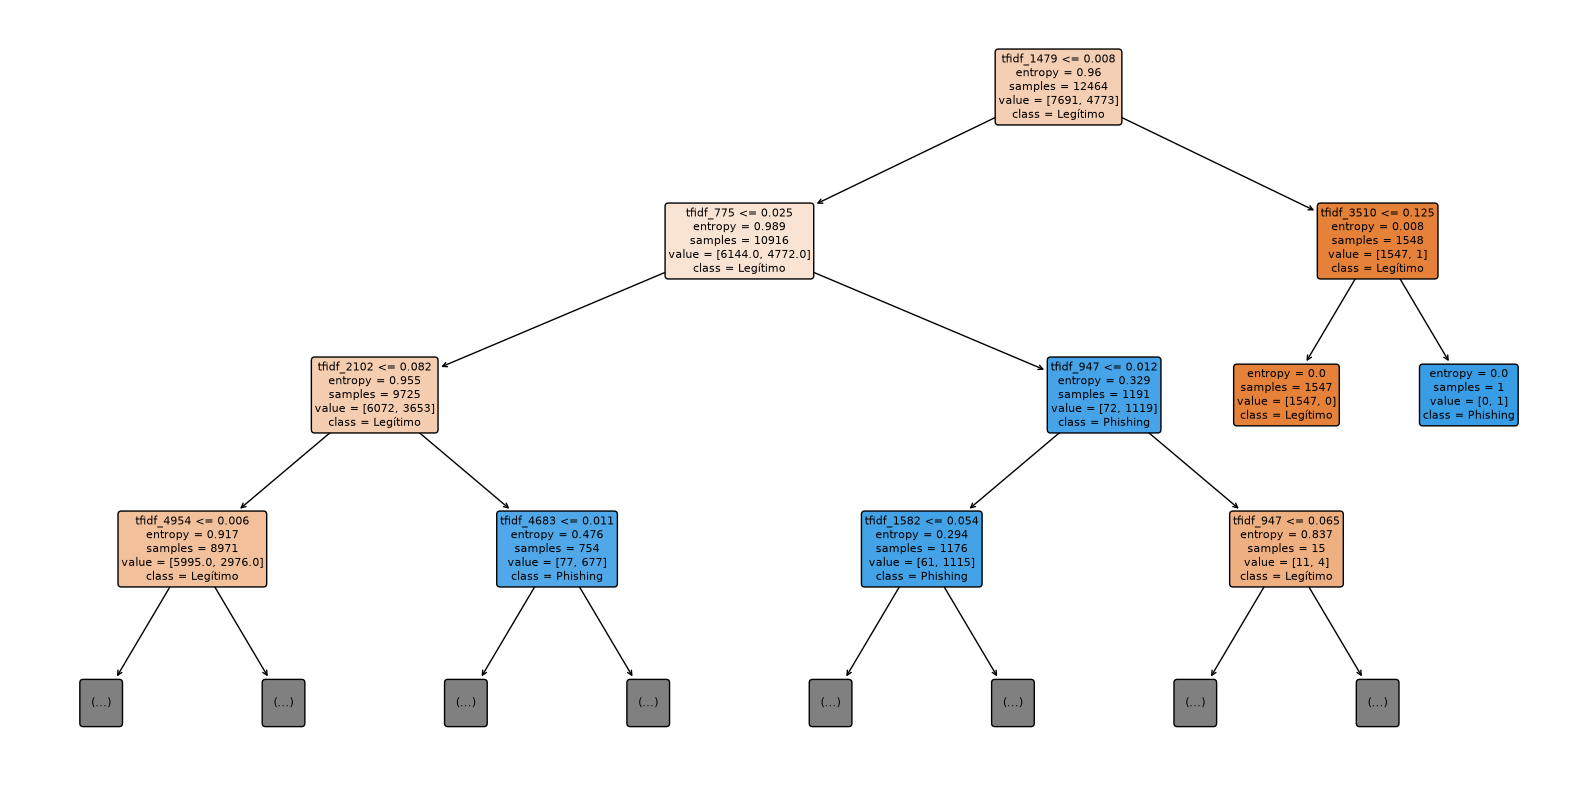

In [4]:
feature_names = [f"tfidf_{i}" for i in range(X_train.shape[1])]

plt.figure(figsize=(20, 10))
plot_tree(classification, feature_names=feature_names, class_names=['Legítimo', 'Phishing'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()

#### Análisis matriz de confusión

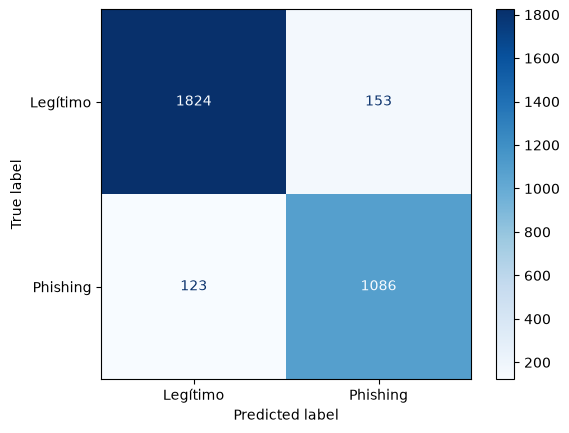

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [6]:
cm_tree = confusion_matrix(y_test, y_pred)
P = cm_tree[1, :].sum()
N = cm_tree[0, :].sum()
TP = cm_tree[1, 1]
TN = cm_tree[0, 0]

TPR_tree = TP / P
TNR_tree = TN / N
balanced_accuracy_tree = (TPR_tree + TNR_tree) / 2

precision_tree = precision_score(y_test, y_pred, zero_division=0)
recall_tree = recall_score(y_test, y_pred, zero_division=0)
f1_tree = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_tree:.4f}")
print(f"Precisión:               {precision_tree:.4f}")
print(f"Sensibilidad (Recall):   {TPR_tree:.4f}")
print(f"F1-score:                {f1_tree:.4f}")
print(f"Especificidad:           {TNR_tree:.4f}")
print(f"Recuperación (Recall):   {recall_tree:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9104
Precisión:               0.8765
Sensibilidad (Recall):   0.8983
F1-score:                0.8873
Especificidad:           0.9226
Recuperación (Recall):   0.8983
Tiempo de entrenamiento: 0:00:04.152196
Tiempo de predicción:    0:00:00.004505


#### Curva Roc

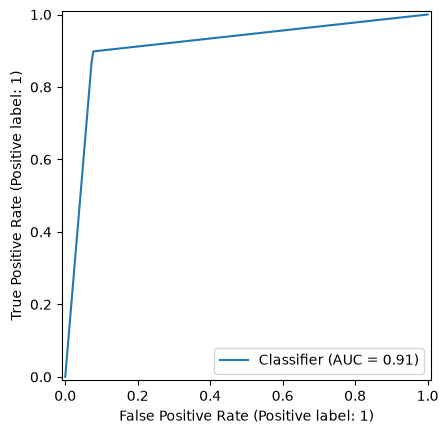

In [7]:
y_scores = classification.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

#### Profunidad y features

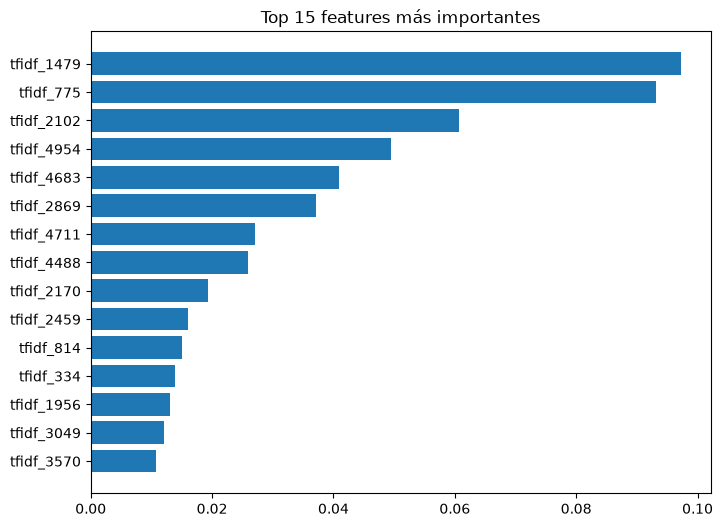

Profundidad del árbol: 279
Cantidad de hojas: 616


In [8]:
importances = classification.feature_importances_
top_idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8,6))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx])
plt.title('Top 15 features más importantes')
plt.show()

print(f"Profundidad del árbol: {classification.get_depth()}")
print(f"Cantidad de hojas: {classification.get_n_leaves()}")